In [13]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as dp

# 피처 추가 후 저장

In [14]:
apple = pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/overseas/애플.csv')
tesla = pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/overseas/테슬라.csv')
cell = pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/domestic/셀트리온.csv')
kbfin = pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/domestic/KB금융.csv')

In [15]:
cell.drop(columns=['Capital Gains'], inplace=True)
cell

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-06-25 00:00:00+09:00,267019.53125,273367.06250,266173.187500,267442.718750,1085109,0.0,0.0
1,2020-06-26 00:00:00+09:00,270828.06250,271674.40625,260248.843750,264480.531250,1096312,0.0,0.0
2,2020-06-29 00:00:00+09:00,267865.87500,275906.09375,263211.031250,263211.031250,1563485,0.0,0.0
3,2020-06-30 00:00:00+09:00,264057.34375,266173.18750,253054.968750,258979.328125,1792589,0.0,0.0
4,2020-07-01 00:00:00+09:00,260672.00000,261518.34375,250515.953125,251785.468750,1195800,0.0,0.0
...,...,...,...,...,...,...,...,...
1219,2025-06-18 00:00:00+09:00,160600.00000,163200.00000,160400.000000,162300.000000,411730,0.0,0.0
1220,2025-06-19 00:00:00+09:00,162300.00000,162300.00000,159600.000000,160200.000000,387741,0.0,0.0
1221,2025-06-20 00:00:00+09:00,160500.00000,163900.00000,160100.000000,162200.000000,958664,0.0,0.0
1222,2025-06-23 00:00:00+09:00,160400.00000,160800.00000,158400.000000,159000.000000,427725,0.0,0.0


In [16]:
def generate_all_features(df):
    # 수익률 및 라벨
    df['PriceChange_1d'] = df['Close'].pct_change().shift(-1)
    df['PriceChange_5d'] = df['Close'].pct_change(5).shift(-5)
    df['Label_1d'] = (df['PriceChange_1d'] > 0).astype(int)

    # RSI
    df['RSI'] = ta.rsi(df['Close'], length=14)

    # MACD & Histogram
    macd = ta.macd(df['Close'])
    df['MACD'] = macd['MACD_12_26_9']
    df['MACD_H'] = macd['MACDh_12_26_9']

    # OBV
    df['OBV'] = ta.obv(df['Close'], df['Volume'])

    # Bollinger Bands
    bbands = ta.bbands(df['Close'], length=20)
    df['BBL'] = bbands['BBL_20_2.0']
    df['BBM'] = bbands['BBM_20_2.0']
    df['BBU'] = bbands['BBU_20_2.0']

    # Stochastic Oscillator
    stoch = ta.stoch(df['High'], df['Low'], df['Close'])
    df['STOCHk'] = stoch['STOCHk_14_3_3']
    df['STOCHd'] = stoch['STOCHd_14_3_3']

    # 평균선들
    df['SMA_20'] = ta.sma(df['Close'], length=20)
    df['EMA_50'] = ta.ema(df['Close'], length=50)
    df['SMA_200'] = ta.sma(df['Close'], length=200)

    # ROC & CCI
    df['ROC'] = ta.roc(df['Close'], length=5)
    df['CCI'] = ta.cci(df['High'], df['Low'], df['Close'], length=20)

    return df

In [17]:
# 종목별 생성 및 저장
for name, df in zip(['apple', 'tesla', 'cell', 'kbfin'], [apple, tesla, cell, kbfin]):
    df_feat = generate_all_features(df.copy())
    df_feat.to_csv(f"{name}_features.csv", index=False)
    print(f"{name} 저장 완료. shape = {df_feat.shape}")

apple 저장 완료. shape = (1255, 25)
tesla 저장 완료. shape = (1255, 25)
cell 저장 완료. shape = (1224, 25)
kbfin 저장 완료. shape = (1225, 25)


# 데이터 재로딩 및 EDA

In [18]:
df_app=pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/overseas/apple_features.csv')
df_tes=pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/overseas/tesla_features.csv')
df_kbf=pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/domestic/kbfin_features.csv')
df_cel=pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/domestic/cell_features.csv')

In [19]:
# 예시: AAPL
df_app.corr(numeric_only=True)[['PriceChange_1d', 'PriceChange_5d']].sort_values(by='PriceChange_1d', ascending=False)

,PriceChange_1d,PriceChange_5d
PriceChange_1d,1.000000,0.433351
Label_1d,0.713585,0.300835
PriceChange_5d,0.433351,1.000000
Stock Splits,0.058517,-0.089746
Volume,0.022149,0.069786
CCI,0.002730,-0.024687
Dividends,-0.006643,0.015749
STOCHk,-0.013927,-0.038583
STOCHd,-0.018691,-0.034095
RSI,-0.021811,-0.045854


In [20]:
# 예시: AAPL
corr1=df_app.corr(numeric_only=True)[['Label_1d', 'PriceChange_5d']].sort_values(by='Label_1d', ascending=False)
corr1

,Label_1d,PriceChange_5d
Label_1d,1.000000,0.300835
PriceChange_1d,0.713585,0.433351
PriceChange_5d,0.300835,1.000000
Stock Splits,0.026684,-0.089746
EMA_50,0.006784,-0.090724
Volume,0.003254,0.069786
SMA_200,0.002680,-0.073374
CCI,0.002556,-0.024687
MACD_H,-0.002923,-0.051205
BBU,-0.005057,-0.131674


<Axes: >

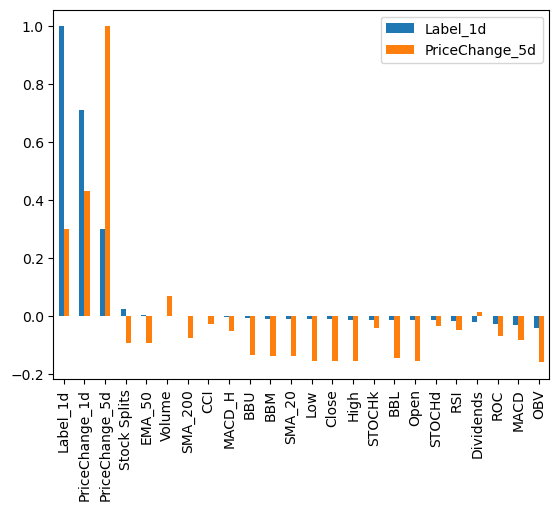

In [21]:
corr1.plot.bar()

In [22]:
df_app.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'PriceChange_1d', 'PriceChange_5d', 'Label_1d', 'RSI',
       'MACD', 'MACD_H', 'OBV', 'BBL', 'BBM', 'BBU', 'STOCHk', 'STOCHd',
       'SMA_20', 'EMA_50', 'SMA_200', 'ROC', 'CCI'],
      dtype='object')

In [23]:
df_app['PriceChange_1d']

0      -0.030726
1       0.023047
2       0.008348
3      -0.001892
4       0.000000
          ...   
1250    0.004805
1251    0.022484
1252    0.002488
1253   -0.005955
1254         NaN
Name: PriceChange_1d, Length: 1255, dtype: float64

<Axes: >

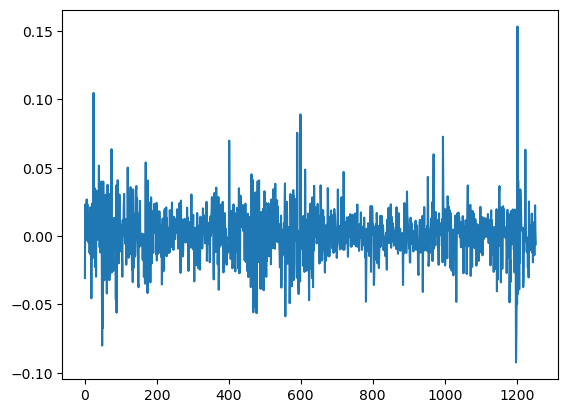

In [24]:
df_app['PriceChange_1d'].plot()

In [25]:
df_app['PriceChange_1d_lag'] = df_app['PriceChange_1d'].shift(-1)
corr_lag = df_app.corr(numeric_only=True)[['PriceChange_1d_lag']].sort_values(by='PriceChange_1d_lag', ascending=False)
print(corr_lag.head(10))


                    PriceChange_1d_lag
PriceChange_1d_lag            1.000000
PriceChange_5d                0.430270
Volume                        0.037890
Dividends                    -0.003042
PriceChange_1d               -0.014932
CCI                          -0.016554
STOCHk                       -0.019822
STOCHd                       -0.020499
Label_1d                     -0.022712
RSI                          -0.025149


In [26]:
df_app['RSI_bin'] = pd.cut(df_app['RSI'], [0, 30, 50, 70, 100])
print(df_app.groupby('RSI_bin')['PriceChange_1d'].mean())


RSI_bin
(0, 30]      0.011441
(30, 50]     0.000467
(50, 70]     0.000692
(70, 100]    0.000844
Name: PriceChange_1d, dtype: float64


/tmp/ipykernel_76966/3065551192.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_app.groupby('RSI_bin')['PriceChange_1d'].mean())


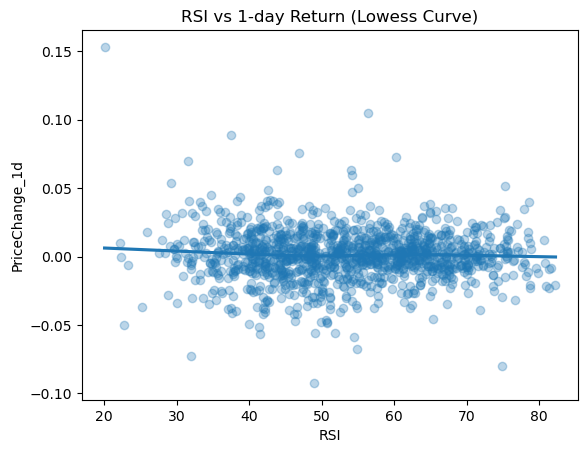

In [27]:
sns.regplot(data=df_app, x='RSI', y='PriceChange_1d', lowess=True, scatter_kws={'alpha':0.3})
plt.title('RSI vs 1-day Return (Lowess Curve)')
plt.show()

/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWar

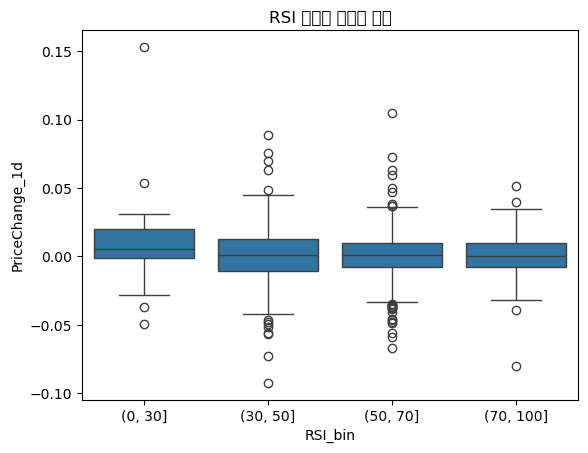

In [28]:
df_app['RSI_bin'] = pd.cut(df_app['RSI'], [0,30,50,70,100])
sns.boxplot(data=df_app, x='RSI_bin', y='PriceChange_1d')
plt.title('RSI 구간별 수익률 분포')
plt.show()

In [29]:
import pandas as pd
import pandas_ta as ta

# 데이터 불러오기
# df_app = pd.read_csv('/home/nshawny/AI project 2/personal_data/stock/overseas/apple_features.csv')

def enrich_features(df):
    # 기술적 지표
    df['SMA_20'] = ta.sma(df['Close'], length=20)
    df['EMA_20'] = ta.ema(df['Close'], length=20)
    df['RSI_14'] = ta.rsi(df['Close'], length=14)

    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD'] = macd['MACD_12_26_9']
    df['MACD_signal'] = macd['MACDs_12_26_9']

    bb = ta.bbands(df['Close'], length=20, std=2)
    df['BBU'] = bb['BBU_20_2.0']
    df['BBM'] = bb['BBM_20_2.0']
    df['BBL'] = bb['BBL_20_2.0']

    stoch = ta.stoch(df['High'], df['Low'], df['Close'], k=14, d=3)
    df['STOCHk'] = stoch['STOCHk_14_3_3']
    df['STOCHd'] = stoch['STOCHd_14_3_3']

    # 새로운 타겟
    df['PriceChange_3d'] = df['Close'].pct_change(periods=3).shift(-3)
    df['MaxGain_5d'] = df['High'].rolling(window=5).max().shift(-5)
    df['MaxGain_5d'] = (df['MaxGain_5d'] - df['Close']) / df['Close']
    df['IsJump_5d'] = (df['MaxGain_5d'] > 0.03).astype(int)

    # 조건 기반 피처
    df['RSI_oversold'] = (df['RSI_14'] <= 30).astype(int)
    df['MACD_cross'] = (df['MACD'] > df['MACD_signal']).astype(int)
    df['BB_touch_lower'] = (df['Close'] <= df['BBL']).astype(int)
    df['STOCH_cross'] = (df['STOCHk'] > df['STOCHd']).astype(int)

    df.dropna(inplace=True)
    return df

df_app_enriched = enrich_features(df_app)
df_app_enriched.to_csv("apple_enriched.csv", index=False)


In [30]:
df_app_enriched

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,PriceChange_1d,PriceChange_5d,...,EMA_20,RSI_14,MACD_signal,PriceChange_3d,MaxGain_5d,IsJump_5d,RSI_oversold,MACD_cross,BB_touch_lower,STOCH_cross
199,2021-04-12 00:00:00-04:00,129.466694,129.789092,127.620241,128.216187,91420000,0.0,0.0,0.024307,0.027430,...,122.740557,62.183502,-0.044150,0.024840,0.032231,1,0,1,0,0
200,2021-04-13 00:00:00-04:00,129.388547,131.557399,128.890288,131.332687,91266500,0.0,0.0,-0.017853,-0.009819,...,123.558855,66.644177,0.338248,-0.002009,0.008183,0,0,1,0,0
201,2021-04-14 00:00:00-04:00,131.830901,131.889516,128.626475,128.987946,87222800,0.0,0.0,0.018708,0.011134,...,124.075911,60.830473,0.679144,0.021283,0.026510,0,0,1,0,0
202,2021-04-15 00:00:00-04:00,130.736706,131.889511,130.560846,131.401031,89347100,0.0,0.0,-0.002528,-0.019033,...,124.773542,64.283660,1.013108,-0.010334,0.007658,0,0,1,0,1
203,2021-04-16 00:00:00-04:00,131.205667,131.567137,130.209164,131.068893,84922400,0.0,0.0,0.005068,0.001192,...,125.373099,63.454450,1.317612,-0.004919,0.010212,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,2025-06-10 00:00:00-04:00,200.600006,204.350006,200.570007,202.669998,54672600,0.0,0.0,-0.019194,-0.034687,...,202.818212,48.910651,-1.106792,-0.030690,0.009029,0,0,1,0,1
1246,2025-06-11 00:00:00-04:00,203.500000,204.500000,198.410004,198.779999,60989900,0.0,0.0,0.002113,-0.011067,...,202.433620,43.656713,-1.115222,-0.001811,0.007999,0,0,0,0,0
1247,2025-06-12 00:00:00-04:00,199.080002,199.679993,197.360001,199.199997,43904600,0.0,0.0,-0.013805,0.009036,...,202.125656,44.351762,-1.146426,-0.017871,0.012550,0,0,0,0,0
1248,2025-06-13 00:00:00-04:00,199.729996,200.369995,195.699997,196.449997,51447300,0.0,0.0,0.010028,0.025706,...,201.585117,40.802560,-1.231530,0.000662,0.029779,0,0,0,0,0


In [31]:
# 1. RSI ≤ 30 and MACD > Signal
cond1 = (df_app_enriched['RSI_14'] <= 30) & (df_app_enriched['MACD'] > df_app_enriched['MACD_signal'])
mean1 = df_app_enriched.loc[cond1, 'PriceChange_3d'].mean()
print("RSI_oversold + MACD_cross 평균 수익률:", round(mean1 * 100, 3), "%")

# 2. BB touch lower and OBV rising
df_app_enriched['OBV_rising'] = df_app_enriched['OBV'].diff() > 0
cond2 = (df_app_enriched['BB_touch_lower'] == 1) & (df_app_enriched['OBV_rising'])
mean2 = df_app_enriched.loc[cond2, 'PriceChange_3d'].mean()
print("BB 하단 접촉 + OBV 증가 평균 수익률:", round(mean2 * 100, 3), "%")

# 3. STOCHk > 80 and MACD < Signal
cond3 = (df_app_enriched['STOCHk'] > 80) & (df_app_enriched['MACD'] < df_app_enriched['MACD_signal'])
mean3 = df_app_enriched.loc[cond3, 'PriceChange_3d'].mean()
print("과매수 + MACD 하락 전환 평균 수익률:", round(mean3 * 100, 3), "%")


RSI_oversold + MACD_cross 평균 수익률: nan %
BB 하단 접촉 + OBV 증가 평균 수익률: -0.896 %
과매수 + MACD 하락 전환 평균 수익률: 0.338 %


In [40]:
import numpy as np

# RSI < 30인 시점 찾기
signal_idx = df_app_enriched[df_app_enriched['RSI_14'] < 30].index

# 3일 후 수익률 평균 구할 리스트
returns = []

for idx in signal_idx:
    if idx + 3 < len(df_app_enriched):
        future_return = df_app_enriched.loc[idx + 3, 'Close'] / df_app_enriched.loc[idx, 'Close'] - 1
        returns.append(future_return)

# 평균 수익률 출력
print(f"RSI<30 조건 만족 시점에서 3일 후 평균 수익률: {np.mean(returns):.4f}")


RSI<30 조건 만족 시점에서 3일 후 평균 수익률: 0.0127


In [41]:
from scipy.stats import ttest_ind

# signal: RSI < 30 조건 만족 시점에서의 3일 후 수익률
signal_returns = np.array(returns)

# 전체: 3일 후 수익률 전체 (조건 무관)
overall_returns = df_app_enriched['PriceChange_3d'].dropna().values

# Welch's t-test (등분산 가정하지 않음)
t_stat, p_val = ttest_ind(signal_returns, overall_returns, equal_var=False)

print(f"평균 수익률 (신호조건): {np.mean(signal_returns):.4f}")
print(f"평균 수익률 (전체): {np.mean(overall_returns):.4f}")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


평균 수익률 (신호조건): 0.0127
평균 수익률 (전체): 0.0017
t-statistic: 1.6583, p-value: 0.1221


In [39]:
from sklearn.feature_selection import mutual_info_classif
X = df_app_enriched[['RSI_14', 'MACD', 'OBV', 'BB_touch_lower', 'MACD_cross']].fillna(0)
y = df_app_enriched['Label_1d']
mi = mutual_info_classif(X, y, discrete_features='auto')
pd.DataFrame({'feature': X.columns, 'mi_score': mi}).sort_values('mi_score', ascending=False)

,feature,mi_score
1,MACD,0.011881
0,RSI_14,0.011516
2,OBV,0.000000
3,BB_touch_lower,0.000000
4,MACD_cross,0.000000


In [43]:
df_app_enriched['MACD_diff'] = df_app_enriched['MACD'] - df_app_enriched['MACD_signal']

# 조건: MACD_diff > 0.5
cond_idx = df_app_enriched[df_app_enriched['MACD_diff'] > 0.5].index

macd_returns = []
for i in cond_idx:
    if i + 3 < len(df_app_enriched):
        r = df_app_enriched.loc[i + 3, 'Close'] / df_app_enriched.loc[i, 'Close'] - 1
        macd_returns.append(r)

print(f"[MACD_diff > 0.5] 3일 후 평균 수익률: {np.mean(macd_returns):.4f}")


[MACD_diff > 0.5] 3일 후 평균 수익률: 0.0027


In [44]:
df_app_enriched['STOCH_diff'] = df_app_enriched['STOCHk'] - df_app_enriched['STOCHd']

# 조건: 골든크로스 (%K가 %D를 상향 돌파)
cross_idx = df_app_enriched[(df_app_enriched['STOCH_diff'] > 0) & (df_app_enriched['STOCH_diff'].shift(1) < 0)].index

stoch_returns = []
for i in cross_idx:
    if i + 3 < len(df_app_enriched):
        r = df_app_enriched.loc[i + 3, 'Close'] / df_app_enriched.loc[i, 'Close'] - 1
        stoch_returns.append(r)

print(f"[Stochastic 골든크로스] 3일 후 평균 수익률: {np.mean(stoch_returns):.4f}")


[Stochastic 골든크로스] 3일 후 평균 수익률: -0.0010


In [45]:
cond_idx = df_app_enriched[(df_app_enriched['Close'] < df_app_enriched['BBL']) & (df_app_enriched['OBV'].diff() > 0)].index

combo_returns = []
for i in cond_idx:
    if i + 3 < len(df_app_enriched):
        r = df_app_enriched.loc[i + 3, 'Close'] / df_app_enriched.loc[i, 'Close'] - 1
        combo_returns.append(r)

print(f"[BB 하단 접촉 + OBV 상승] 3일 후 평균 수익률: {np.mean(combo_returns):.4f}")


[BB 하단 접촉 + OBV 상승] 3일 후 평균 수익률: -0.0090


/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarn

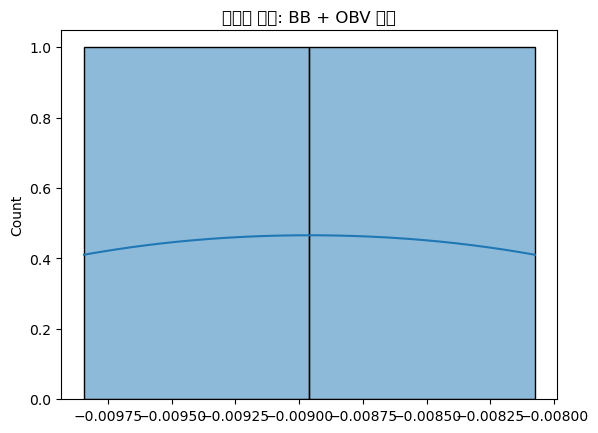

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(combo_returns, kde=True)
plt.title("수익률 분포: BB + OBV 조합")
plt.show()
